<a href="https://colab.research.google.com/github/diogenesjusto/FIAP/blob/master/Gradua%C3%A7%C3%A3o/2025/20251018_CodigoPycaret_e_Importancia_Variaveis_atualizado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install git+https://github.com/pycaret/pycaret.git@master --upgrade

  Cloning https://github.com/pycaret/pycaret.git (to revision master) to /tmp/pip-req-build-su3vhn13
  Running command git clone --filter=blob:none --quiet https://github.com/pycaret/pycaret.git /tmp/pip-req-build-su3vhn13
  Resolved https://github.com/pycaret/pycaret.git to commit 58ec3c282d58e94727f9d5b77b49f241e9103ab3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
from pycaret.classification import *

In [2]:
# Carga de dados
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/diogenesjusto/FIAP/master/dados/train.csv")

In [3]:
pycDF = setup(data=df, target='Survived' )

,Description,Value
0,Session id,4470
1,Target,Survived
2,Target type,Binary
3,Original data shape,"(891, 12)"
4,Transformed data shape,"(891, 14)"
5,Transformed train set shape,"(623, 14)"
6,Transformed test set shape,"(268, 14)"
7,Numeric features,6
8,Categorical features,5
9,Rows with missing values,79.5%


In [4]:
best = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.8009,0.8645,0.6694,0.7832,0.7203,0.5674,0.5728,0.8450
ridge,Ridge Classifier,0.7624,0.8526,0.4560,0.8608,0.5942,0.4484,0.4945,0.1140
et,Extra Trees Classifier,0.7126,0.8001,0.2886,0.8856,0.4305,0.3026,0.3882,0.2340
nb,Naive Bayes,0.6532,0.7813,0.1504,0.7210,0.2381,0.1348,0.2004,0.0950
knn,K Neighbors Classifier,0.6403,0.6032,0.3630,0.5518,0.4325,0.1867,0.1979,0.1810
rf,Random Forest Classifier,0.6308,0.8487,0.0543,0.5833,0.0950,0.0523,0.1124,0.3220
lda,Linear Discriminant Analysis,0.6260,0.5371,0.0304,0.0875,0.0452,0.0322,0.0402,0.0950
dt,Decision Tree Classifier,0.6164,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0930
qda,Quadratic Discriminant Analysis,0.6164,0.4849,0.0000,0.0000,0.0000,0.0000,0.0000,0.1430
ada,Ada Boost Classifier,0.6164,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1680


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [5]:
evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#Avaliação de Importância de Variáveis

In [6]:
import numpy as np

dummy_sex = pd.get_dummies(df['Sex'])

df['Sex_female'] = dummy_sex['female']

dummy_pclass = pd.get_dummies(df['Pclass'], prefix='Class')
df['Class_1'] = dummy_pclass['Class_1']
df['Class_2'] = dummy_pclass['Class_2']

df['Women_or_Children'] = np.where(
  df['Age']<14,
  1,
  np.where(
      df['Sex_female']==1,
      1,
      0
  )
)

In [10]:
from sklearn.inspection import permutation_importance

from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X_treino, X_teste, Y_treino, Y_teste = train_test_split(
  df[['Class_1', 'Class_2', 'Sex_female', 'Women_or_Children']],
  df['Survived'],
  test_size=0.25, random_state=2
  )

mod = RandomForestClassifier().fit(X_treino, Y_treino)


Text(0.5, 0, 'Permutation Importance')

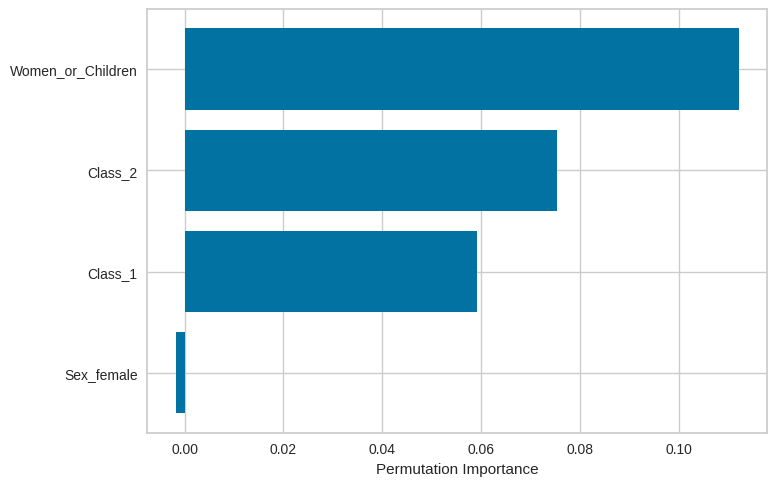

In [11]:
# O método de permutação permite que generalizemos, ou seja, utilizemos avaliação de importância para qualquer algoritmo
perm_importance = permutation_importance(mod, X_teste, Y_teste)

ordem_idx = perm_importance.importances_mean.argsort()
plt.barh(X_teste.columns[ordem_idx], perm_importance.importances_mean[ordem_idx])
plt.xlabel("Permutation Importance")